# двойной маятник

Два точечных груза $m_1$, $m_2$ на невесомых стержнях длины $l_1$, $l_2$. Трения нет.
Углы $\theta_1$, $\theta_2$ отсчитываются от вертикали вниз; $v_1=\dot\theta_1$, $v_2=\dot\theta_2$, $\delta=\theta_1-\theta_2$.

Уравнения движения:
$$
(m_1+m_2)l_1\ddot\theta_1+m_2l_2\cos\delta\,\ddot\theta_2
=-(m_1+m_2)g\sin\theta_1-m_2l_2v_2^2\sin\delta,
$$
$$
l_2\ddot\theta_2+l_1\cos\delta\,\ddot\theta_1
=l_1v_1^2\sin\delta-g\sin\theta_2.
$$

Решаем систему для $y=(\theta_1,\theta_2,v_1,v_2)$ без линеаризации.
Начальные углы — 0.1 и 0.05 рад, скорости нулевые. Массы — по 1 кг, длины — по 1 м.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81
m_1 = m_2 = 1.0
l_1 = l_2 = 1.0
y_0 = np.array([0.1, 0.05, 0.0, 0.0])
t_end = 12.0
steps = [0.04, 0.02, 0.01]


Для $\dot y=f(y)$ шаг rk4 имеет вид
$$
k_1=f(y_n),\quad k_2=f(y_n+hk_1/2),\quad
k_3=f(y_n+hk_2/2),\quad k_4=f(y_n+hk_3),
$$
$$y_{n+1}=y_n+\frac{h}{6}(k_1+2k_2+2k_3+k_4).$$

Метод Адамса–Бэшфорта второго порядка:
$$y_{n+1}=y_n+\frac{h}{2}\bigl(3f(y_n)-f(y_{n-1})\bigr).$$
Первое значение $y_1$ для него получаем одним шагом rk4.


In [2]:
def rhs(y):  # правая часть системы
    theta_1, theta_2, v_1, v_2 = y
    delta = theta_1 - theta_2
    c = np.cos(delta)
    s = np.sin(delta)
    b_1 = -(m_1 + m_2) * g * np.sin(theta_1) - m_2 * l_2 * v_2**2 * s
    b_2 = l_1 * v_1**2 * s - g * np.sin(theta_2)
    a_1 = (b_1 - m_2 * c * b_2) / (l_1 * (m_1 + m_2 * s**2))
    a_2 = (b_2 - l_1 * c * a_1) / l_2
    return np.array([v_1, v_2, a_1, a_2])


def rk4_step(y, h):  # шаг rk4
    k_1 = rhs(y)
    k_2 = rhs(y + h * k_1 / 2)
    k_3 = rhs(y + h * k_2 / 2)
    k_4 = rhs(y + h * k_3)
    return y + h * (k_1 + 2 * k_2 + 2 * k_3 + k_4) / 6


def solve(method, h):  # расчёт на временной сетке
    n = round(t_end / h)
    t = np.linspace(0, t_end, n + 1)
    dt = t[1] - t[0]
    y = np.empty((n + 1, 4))
    y[0] = y_0
    if method == 'rk4':
        for i in range(n):
            y[i + 1] = rk4_step(y[i], dt)
    elif method == 'ab2':
        y[1] = rk4_step(y[0], dt)
        f_prev = rhs(y[0])
        for i in range(1, n):
            f = rhs(y[i])
            y[i + 1] = y[i] + dt * (3 * f - f_prev) / 2
            f_prev = f
    else:
        raise ValueError('неизвестный метод')
    return t, y


Координаты нижнего груза относительно точки подвеса:
$$x_2=l_1\sin\theta_1+l_2\sin\theta_2,\qquad
z_2=-l_1\cos\theta_1-l_2\cos\theta_2.$$

Полная энергия $E=T+U$, где
$$
T=\frac{(m_1+m_2)l_1^2v_1^2}{2}+\frac{m_2l_2^2v_2^2}{2}
+m_2l_1l_2v_1v_2\cos\delta,
$$
$$U=(m_1+m_2)gl_1(1-\cos\theta_1)+m_2gl_2(1-\cos\theta_2).$$
Нуль потенциальной энергии выбран в нижнем положении равновесия. Без трения $E(t)=E(0)$.


In [3]:
def lower_position(y):  # координаты нижнего груза
    theta_1, theta_2 = y[:, 0], y[:, 1]
    x = l_1 * np.sin(theta_1) + l_2 * np.sin(theta_2)
    z = -l_1 * np.cos(theta_1) - l_2 * np.cos(theta_2)
    return x, z


def energy(y):  # полная механическая энергия
    theta_1, theta_2, v_1, v_2 = y.T
    e_k = ((m_1 + m_2) * l_1**2 * v_1**2 / 2
           + m_2 * l_2**2 * v_2**2 / 2
           + m_2 * l_1 * l_2 * v_1 * v_2 * np.cos(theta_1 - theta_2))
    e_p = (2 * (m_1 + m_2) * g * l_1 * np.sin(theta_1 / 2)**2
           + 2 * m_2 * g * l_2 * np.sin(theta_2 / 2)**2)
    return e_k + e_p


results = []
for h in steps:
    t, y_rk4 = solve('rk4', h)
    _, y_ab2 = solve('ab2', h)
    results.append((t, y_rk4, y_ab2))

names = ['rk4', 'Адамс–Бэшфорт']
colors = ['tab:blue', 'tab:orange']
styles = ['-', '--']
e_0 = energy(y_0)


## углы и траектория


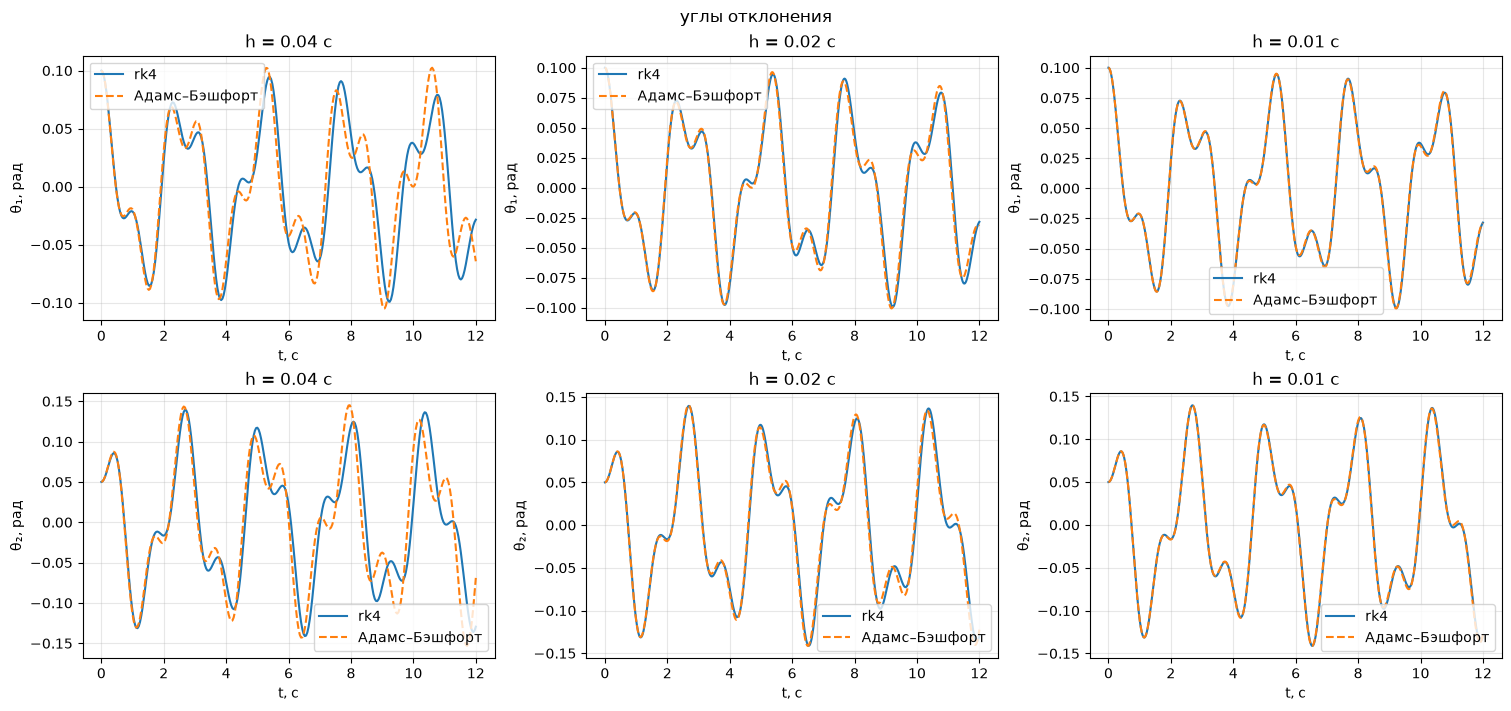

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
for j, (h, (t, *solutions)) in enumerate(zip(steps, results)):
    for y, name, color, style in zip(solutions, names, colors, styles):
        axes[0, j].plot(t, y[:, 0], label=name, color=color, linestyle=style)
        axes[1, j].plot(t, y[:, 1], label=name, color=color, linestyle=style)
    for i, label in enumerate(['θ₁, рад', 'θ₂, рад']):
        axes[i, j].set(title=f'h = {h} с', xlabel='t, с', ylabel=label)
        axes[i, j].grid(alpha=0.3)
        axes[i, j].legend()
fig.suptitle('углы отклонения')
plt.show()


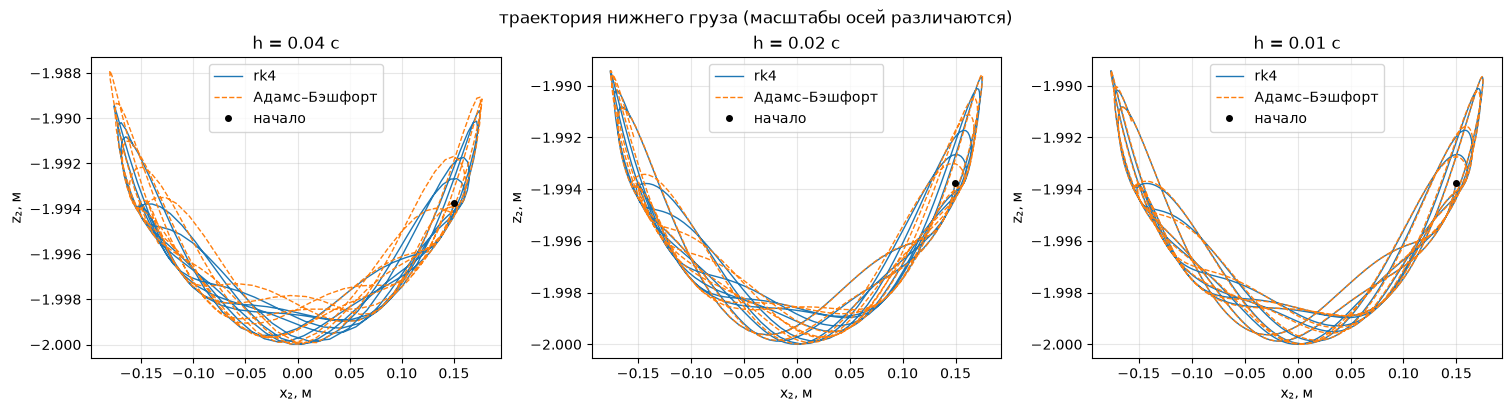

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, h, (t, *solutions) in zip(axes, steps, results):
    for y, name, color, style in zip(solutions, names, colors, styles):
        x, z = lower_position(y)
        ax.plot(x, z, label=name, color=color, linestyle=style, linewidth=1)
    x_0, z_0 = lower_position(y_0[None, :])
    ax.plot(x_0, z_0, 'ko', markersize=4, label='начало', zorder=5)
    ax.set(title=f'h = {h} с', xlabel='x₂, м', ylabel='z₂, м')
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('траектория нижнего груза (масштабы осей различаются)')
plt.show()


## полная энергия

Для каждого метода показаны все три шага. Масштабы оси энергии на двух графиках различаются.


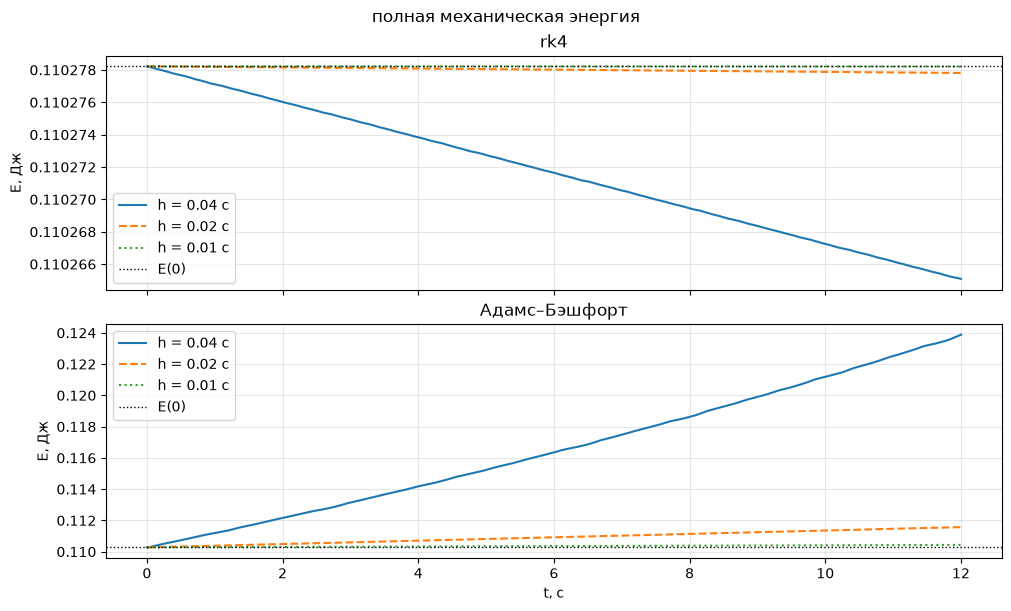

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
step_colors = ['tab:blue', 'tab:orange', 'tab:green']
step_styles = ['-', '--', ':']
for i, (ax, name) in enumerate(zip(axes, names)):
    for h, (t, *solutions), color, style in zip(steps, results, step_colors, step_styles):
        ax.plot(t, energy(solutions[i]), label=f'h = {h} с', color=color, linestyle=style)
    ax.axhline(e_0, color='black', linestyle=':', linewidth=1, label='E(0)')
    ax.set(title=name, ylabel='E, Дж')
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    ax.grid(alpha=0.3)
    ax.legend()
axes[1].set_xlabel('t, с')
fig.suptitle('полная механическая энергия')
plt.show()


## сравнение шагов

Численный эталон — расчёт rk4 с шагом 0.0005 с. Ошибки углов измеряем в общих узлах сеток на интервале 0–12 с:
$$\varepsilon_j=\max_n|\theta_{j,n}-\theta_{j,\mathrm{эт}}(t_n)|,\qquad
\varepsilon_E=\max_n\frac{|E_n-E_0|}{E_0}\cdot100\%.$$


In [7]:
h_ref = 0.0005
t_ref, y_ref = solve('rk4', h_ref)

print(f"{'шаг, с':>8} {'метод':>15} {'ошибка θ₁, рад':>18} {'ошибка θ₂, рад':>18} {'ошибка E, %':>16}")
for h, (t, *solutions) in zip(steps, results):
    indices = np.rint(t / (t_ref[1] - t_ref[0])).astype(int)
    for name, y in zip(names, solutions):
        errors = np.max(np.abs(y[:, :2] - y_ref[indices, :2]), axis=0)
        energy_error = 100 * np.max(np.abs(energy(y) - e_0)) / e_0
        print(f'{h:8.2f} {name:>15} {errors[0]:18.6e} {errors[1]:18.6e} {energy_error:16.6e}')


  шаг, с           метод     ошибка θ₁, рад     ошибка θ₂, рад      ошибка E, %
    0.04             rk4       5.017207e-05       7.207037e-05     1.191192e-02
    0.04   Адамс–Бэшфорт       5.456666e-02       7.571661e-02     1.233278e+01
    0.02             rk4       3.168413e-06       4.551269e-06     3.739574e-04
    0.02   Адамс–Бэшфорт       1.336567e-02       1.812364e-02     1.167608e+00
    0.01             rk4       1.994468e-07       2.861833e-07     1.168445e-05
    0.01   Адамс–Бэшфорт       3.324345e-03       4.471413e-03     1.397813e-01


При уменьшении шага решения обоих методов сближаются. Ошибка углов у rk4 уменьшается примерно в 16 раз при делении шага пополам, у метода Адамса–Бэшфорта — примерно в 4 раза.
У метода Адамса–Бэшфорта заметны накопление фазовой ошибки и рост энергии. У rk4 отклонение энергии существенно меньше. Изменение энергии здесь связано с численным методом: в исходной системе трения нет.
